# Baselines and Feature Ablation

This notebook establishes linear baselines and conducts a feature ablation study.
All experiments use the **identical** train/test split (seed=42, 80/20) and
5-fold KFold (seed=42, shuffle=True) used in `random_forest.ipynb` and `alternatives.ipynb`.

## Split structure (shared across all notebooks)
```
Full dataset  (216 samples)
  └─ Test set   (44 samples, 20%)  ← touched once, at the very end
  └─ Train set  (172 samples, 80%) ← used for training + KFold CV
       └─ NN only: further split 60/20 (train 129 / val 43) for early stopping
```

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate, KFold
)
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Determinism ──────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cpu')  # run on CPU for reproducibility

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12})

print(f'PyTorch {torch.__version__} | device={DEVICE} | seed={SEED}')

PyTorch 2.5.1+cpu | device=cpu | seed=42


## Data loading and shared split

In [2]:
df = pd.read_csv('../data/raw/hepg2.csv')
print(f'Dataset: {df.shape[0]} samples x {df.shape[1]} columns')

X_raw = df[['% DMSO', 'TREHALOSE']].values
y     = df['VIABILIDADE'].values

# ── Shared 80/20 split (identical to random_forest.ipynb and alternatives.ipynb) ──
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED
)

# ── Shared KFold (identical to random_forest.ipynb and alternatives.ipynb) ──
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Train: {X_train_raw.shape[0]} | Test: {X_test_raw.shape[0]}')

Dataset: 216 samples x 6 columns
Train: 172 | Test: 44


## Polynomial feature engineering (shared)

Used by the polynomial baseline and the PyTorch NN.  
**Fitted on training data only** to prevent leakage.

In [3]:
# Polynomial features (degree=2, no bias term because LinearRegression adds it)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_raw)   # fit on train only
X_test_poly  = poly.transform(X_test_raw)

feature_names_poly = poly.get_feature_names_out(['DMSO', 'Trehalose'])
print('Polynomial features:', list(feature_names_poly))

# Scaled versions (for SVR / MLP / linear models — same StandardScaler)
scaler_raw  = StandardScaler()
X_train_scaled_raw  = scaler_raw.fit_transform(X_train_raw)
X_test_scaled_raw   = scaler_raw.transform(X_test_raw)

scaler_poly = StandardScaler()
X_train_scaled_poly = scaler_poly.fit_transform(X_train_poly)
X_test_scaled_poly  = scaler_poly.transform(X_test_poly)

print(f'Raw features shape: {X_train_raw.shape[1]} | Poly features: {X_train_poly.shape[1]}')

Polynomial features: ['DMSO', 'Trehalose', 'DMSO^2', 'DMSO Trehalose', 'Trehalose^2']
Raw features shape: 2 | Poly features: 5


## Baseline 1 — Linear Regression (raw features)

In [4]:
lr = LinearRegression()
lr.fit(X_train_raw, y_train)

y_pred_lr = lr.predict(X_test_raw)
r2_lr_test  = r2_score(y_test, y_pred_lr)
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_lr))

cv_lr = cross_val_score(lr, X_train_raw, y_train, cv=cv, scoring='r2')
r2_lr_cv = cv_lr.mean()

print(f'Linear Regression (raw): R²(test)={r2_lr_test:.4f} | RMSE(test)={rmse_lr_test:.4f} | R²(CV)={r2_lr_cv:.4f}')

Linear Regression (raw): R²(test)=0.4775 | RMSE(test)=25.5001 | R²(CV)=0.3399


## Baseline 2 — Polynomial Regression degree 2 (correct baseline for NN)

In [5]:
# Polynomial regression = LinearRegression on PolynomialFeatures
# This is the minimal non-linear baseline for the PyTorch NN that uses poly features.
pr = LinearRegression()
pr.fit(X_train_poly, y_train)

y_pred_pr = pr.predict(X_test_poly)
r2_pr_test  = r2_score(y_test, y_pred_pr)
rmse_pr_test = np.sqrt(mean_squared_error(y_test, y_pred_pr))

# CV must use poly-transformed features consistently — build a pipeline
poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',   LinearRegression())
])
cv_pr = cross_val_score(poly_pipeline, X_train_raw, y_train, cv=cv, scoring='r2')
r2_pr_cv = cv_pr.mean()

print(f'Polynomial Regression (deg=2): R²(test)={r2_pr_test:.4f} | RMSE(test)={rmse_pr_test:.4f} | R²(CV)={r2_pr_cv:.4f}')

Polynomial Regression (deg=2): R²(test)=0.6096 | RMSE(test)=22.0430 | R²(CV)=0.3787


## Reference models (re-trained with identical split)

In [6]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf.fit(X_train_raw, y_train)
y_pred_rf = rf.predict(X_test_raw)
r2_rf_test  = r2_score(y_test, y_pred_rf)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf_cv = cross_val_score(rf, X_train_raw, y_train, cv=cv, scoring='r2').mean()
print(f'Random Forest:          R²(test)={r2_rf_test:.4f} | RMSE={rmse_rf_test:.4f} | R²(CV)={r2_rf_cv:.4f}')

# XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=SEED, verbosity=0)
xgb.fit(X_train_raw, y_train)
y_pred_xgb = xgb.predict(X_test_raw)
r2_xgb_test  = r2_score(y_test, y_pred_xgb)
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb_cv = cross_val_score(xgb, X_train_raw, y_train, cv=cv, scoring='r2').mean()
print(f'XGBoost:                R²(test)={r2_xgb_test:.4f} | RMSE={rmse_xgb_test:.4f} | R²(CV)={r2_xgb_cv:.4f}')

# MLP sklearn (raw scaled features — same as alternatives.ipynb)
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=SEED, early_stopping=True)
mlp.fit(X_train_scaled_raw, y_train)
y_pred_mlp = mlp.predict(X_test_scaled_raw)
r2_mlp_test  = r2_score(y_test, y_pred_mlp)
rmse_mlp_test = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp_cv = cross_val_score(mlp, X_train_scaled_raw, y_train, cv=cv, scoring='r2').mean()
print(f'MLP sklearn (raw):      R²(test)={r2_mlp_test:.4f} | RMSE={rmse_mlp_test:.4f} | R²(CV)={r2_mlp_cv:.4f}')

# SVR (raw scaled features)
svr = SVR(kernel='rbf', C=100, gamma=0.1)
svr.fit(X_train_scaled_raw, y_train)
y_pred_svr = svr.predict(X_test_scaled_raw)
r2_svr_test  = r2_score(y_test, y_pred_svr)
rmse_svr_test = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr_cv = cross_val_score(svr, X_train_scaled_raw, y_train, cv=cv, scoring='r2').mean()
print(f'SVR (raw):              R²(test)={r2_svr_test:.4f} | RMSE={rmse_svr_test:.4f} | R²(CV)={r2_svr_cv:.4f}')

Random Forest:          R²(test)=0.9797 | RMSE=5.0245 | R²(CV)=0.9602


XGBoost:                R²(test)=0.9773 | RMSE=5.3198 | R²(CV)=0.9605


MLP sklearn (raw):      R²(test)=0.6122 | RMSE=21.9697 | R²(CV)=0.5849
SVR (raw):              R²(test)=0.5441 | RMSE=23.8188 | R²(CV)=0.2878


## PyTorch Neural Network (reference — same architecture as neural_network.ipynb)

In [ ]:
class HepatoCryoNN(nn.Module):
    def __init__(self, input_dim=5, dropout_rate=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(64, 32),   nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.network(x)


def train_nn(X_tr, y_tr, X_vl, y_vl, input_dim,
             dropout=0.2, epochs=2000, patience=100, weight_decay=1e-4, seed=SEED):
    """Train one neural-network instance and return the best checkpoint found during validation."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
    y_tr_t = torch.FloatTensor(y_tr).unsqueeze(1).to(DEVICE)
    X_vl_t = torch.FloatTensor(X_vl).to(DEVICE)
    y_vl_t = torch.FloatTensor(y_vl).unsqueeze(1).to(DEVICE)

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=32, shuffle=True, drop_last=True,
        generator=torch.Generator().manual_seed(seed)
    )

    model_nn = HepatoCryoNN(input_dim=input_dim, dropout_rate=dropout).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_nn.parameters(), lr=0.001, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-6
    )

    best_val_loss = float('inf')
    best_epoch = 0
    no_improve = 0
    best_state = None

    for epoch in range(epochs):
        model_nn.train()
        for X_b, y_b in loader:
            optimizer.zero_grad()
            loss = criterion(model_nn(X_b), y_b)
            loss.backward()
            optimizer.step()

        model_nn.eval()
        with torch.no_grad():
            val_loss = criterion(model_nn(X_vl_t), y_vl_t).item()
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            no_improve = 0
            best_state = {k: v.clone() for k, v in model_nn.state_dict().items()}
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    model_nn.load_state_dict(best_state)
    model_nn.eval()
    return model_nn, best_epoch, best_val_loss


def eval_nn(model_nn, X_sc, y_true):
    """Return R² and RMSE for a fitted NN."""
    with torch.no_grad():
        preds = model_nn(torch.FloatTensor(X_sc).to(DEVICE)).cpu().numpy().flatten()
    return r2_score(y_true, preds), np.sqrt(mean_squared_error(y_true, preds))

In [8]:
# ── NN train/val split (60/20/20): val used only for early stopping ──────────
X_tr_raw, X_vl_raw, y_tr, y_vl = train_test_split(
    X_train_raw, y_train, test_size=0.25, random_state=SEED
)
# Poly + scale
poly_nn = PolynomialFeatures(degree=2, include_bias=False)
X_tr_poly = poly_nn.fit_transform(X_tr_raw)
X_vl_poly = poly_nn.transform(X_vl_raw)
X_te_poly = poly_nn.transform(X_test_raw)

sc_nn = StandardScaler()
X_tr_sc = sc_nn.fit_transform(X_tr_poly)
X_vl_sc = sc_nn.transform(X_vl_poly)
X_te_sc = sc_nn.transform(X_te_poly)

print(f'NN split -> train={X_tr_sc.shape[0]}, val={X_vl_sc.shape[0]}, test={X_te_sc.shape[0]}')

print('Training reference NN (poly features)...')
nn_ref, nn_epoch, _ = train_nn(X_tr_sc, y_tr, X_vl_sc, y_vl, input_dim=X_tr_sc.shape[1])

r2_nn_test,  rmse_nn_test  = eval_nn(nn_ref, X_te_sc, y_test)
r2_nn_train, rmse_nn_train = eval_nn(nn_ref, X_tr_sc, y_tr)

print(f'PyTorch NN (poly, early-stop ep={nn_epoch}): R²(test)={r2_nn_test:.4f} | RMSE={rmse_nn_test:.4f}')

NN split -> train=129, val=43, test=44
Training reference NN (poly features)...


PyTorch NN (poly, early-stop ep=381): R²(test)=0.9278 | RMSE=9.4768


## Table 1 — Full model comparison (all models, same split)

In [9]:
results = {
    'Linear Regression (raw)':        {'R2_test': r2_lr_test,  'RMSE_test': rmse_lr_test,  'R2_CV': r2_lr_cv},
    'Polynomial Regression (deg=2)':  {'R2_test': r2_pr_test,  'RMSE_test': rmse_pr_test,  'R2_CV': r2_pr_cv},
    'MLP sklearn (raw)':              {'R2_test': r2_mlp_test, 'RMSE_test': rmse_mlp_test, 'R2_CV': r2_mlp_cv},
    'SVR (raw)':                      {'R2_test': r2_svr_test, 'RMSE_test': rmse_svr_test, 'R2_CV': r2_svr_cv},
    'XGBoost':                        {'R2_test': r2_xgb_test, 'RMSE_test': rmse_xgb_test, 'R2_CV': r2_xgb_cv},
    'Random Forest':                  {'R2_test': r2_rf_test,  'RMSE_test': rmse_rf_test,  'R2_CV': r2_rf_cv},
    'PyTorch NN (poly)':              {'R2_test': r2_nn_test,  'RMSE_test': rmse_nn_test,  'R2_CV': None},
}

df_results = pd.DataFrame(results).T
df_results['RMSE_test'] = df_results['RMSE_test'].round(4)
df_results['R2_test']   = df_results['R2_test'].round(4)
df_results['R2_CV']     = df_results['R2_CV'].round(4)
df_results = df_results.sort_values('R2_test', ascending=False)

print('=== TABLE 1: FULL MODEL COMPARISON (same 80/20 split, same 5-fold CV) ===')
print(df_results.to_string())

df_results.to_csv('../data/comparison_table.csv')
print('\nSaved to ../data/comparison_table.csv')

=== TABLE 1: FULL MODEL COMPARISON (same 80/20 split, same 5-fold CV) ===
                               R2_test  RMSE_test   R2_CV
Random Forest                   0.9797     5.0245  0.9602
XGBoost                         0.9773     5.3198  0.9605
PyTorch NN (poly)               0.9278     9.4768     NaN
MLP sklearn (raw)               0.6122    21.9697  0.5849
Polynomial Regression (deg=2)   0.6096    22.0430  0.3787
SVR (raw)                       0.5441    23.8188  0.2878
Linear Regression (raw)         0.4775    25.5001  0.3399

Saved to ../data/comparison_table.csv


## Table 2 — Feature Ablation

### 2a — Random Forest: raw vs. polynomial features

Expected finding: RF should NOT need polynomial features (tree splits handle
non-linearity natively).

In [10]:
# RF — raw
rf_raw = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_raw.fit(X_train_raw, y_train)
r2_rf_raw_test  = r2_score(y_test, rf_raw.predict(X_test_raw))
r2_rf_raw_cv    = cross_val_score(rf_raw, X_train_raw, y_train, cv=cv, scoring='r2').mean()

# RF — poly
rf_poly = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_poly.fit(X_train_poly, y_train)
r2_rf_poly_test = r2_score(y_test, rf_poly.predict(X_test_poly))
r2_rf_poly_cv   = cross_val_score(rf_poly, X_train_poly, y_train, cv=cv, scoring='r2').mean()

print('=== TABLE 2a: Random Forest — Raw vs. Polynomial Features ===')
df_ablation_rf = pd.DataFrame({
    'Features':  ['Raw [DMSO, Trehalose]', 'Polynomial (deg=2, 5 features)'],
    'R2_test':   [round(r2_rf_raw_test, 4), round(r2_rf_poly_test, 4)],
    'R2_CV':     [round(r2_rf_raw_cv,   4), round(r2_rf_poly_cv,   4)],
})
print(df_ablation_rf.to_string(index=False))
print('\nConclusion: RF with raw features is equivalent to (or better than) RF with poly features,'
      ' confirming trees handle non-linearity natively.')

=== TABLE 2a: Random Forest — Raw vs. Polynomial Features ===
                      Features  R2_test  R2_CV
         Raw [DMSO, Trehalose]   0.9797 0.9602
Polynomial (deg=2, 5 features)   0.9800 0.9561

Conclusion: RF with raw features is equivalent to (or better than) RF with poly features, confirming trees handle non-linearity natively.


### 2b — Neural Network (same architecture): raw vs. polynomial features

Tests whether the NN's poly-feature advantage is due to *representation* (features)
or *architecture* (model expressiveness).

In [11]:
# NN with raw features (scale only)
sc_raw_nn = StandardScaler()
X_tr_sc_raw = sc_raw_nn.fit_transform(X_tr_raw)
X_vl_sc_raw = sc_raw_nn.transform(X_vl_raw)
X_te_sc_raw = sc_raw_nn.transform(X_test_raw)

print('Training NN with RAW features...')
nn_raw, ep_raw, _ = train_nn(
    X_tr_sc_raw, y_tr, X_vl_sc_raw, y_vl, input_dim=X_tr_sc_raw.shape[1]
)
r2_nn_raw_test,  rmse_nn_raw_test  = eval_nn(nn_raw, X_te_sc_raw, y_test)
r2_nn_raw_train, _                 = eval_nn(nn_raw, X_tr_sc_raw, y_tr)

print(f'NN (raw, early-stop ep={ep_raw}): R²(test)={r2_nn_raw_test:.4f} | RMSE={rmse_nn_raw_test:.4f}')

print('\n=== TABLE 2b: Neural Network — Raw vs. Polynomial Features ===')
df_ablation_nn = pd.DataFrame({
    'Features':   ['Raw [DMSO, Trehalose] (2)', 'Polynomial (deg=2, 5)'],
    'R2_test':    [round(r2_nn_raw_test,  4), round(r2_nn_test,  4)],
    'RMSE_test':  [round(rmse_nn_raw_test, 4), round(rmse_nn_test, 4)],
    'Early_stop_epoch': [ep_raw, nn_epoch],
})
print(df_ablation_nn.to_string(index=False))

Training NN with RAW features...


NN (raw, early-stop ep=354): R²(test)=0.8830 | RMSE=12.0651

=== TABLE 2b: Neural Network — Raw vs. Polynomial Features ===
                 Features  R2_test  RMSE_test  Early_stop_epoch
Raw [DMSO, Trehalose] (2)   0.8830    12.0651               354
    Polynomial (deg=2, 5)   0.9278     9.4768               381


## Section 3 — Investigating raw-feature NN underfitting

The NN has heavy regularization (BatchNorm + Dropout 20% × 3 + weight_decay=1e-4 +
early stopping) relative to only 216 samples.  We test whether the lower performance
with raw features is due to **under-training / over-regularization** rather than
architectural limitations.

Variants:
1. Reduce dropout to 0% (no dropout)
2. No BatchNorm
3. Reduce weight decay to 0
4. Increase training budget (patience=200)
5. Combined: no dropout + no BN + wd=0 + patience=200

In [12]:
class HepatoCryoNN_NoBN(nn.Module):
    """Same architecture without BatchNorm."""
    def __init__(self, input_dim=2, dropout_rate=0.2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 64),        nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(64, 32),         nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.network(x)


def train_nn_custom(X_tr, y_tr, X_vl, y_vl, input_dim,
                    dropout=0.2, use_bn=True,
                    epochs=2000, patience=100, weight_decay=1e-4, seed=SEED):
    """Flexible NN trainer for ablation variants."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tr_t = torch.FloatTensor(X_tr).to(DEVICE)
    y_tr_t = torch.FloatTensor(y_tr).unsqueeze(1).to(DEVICE)
    X_vl_t = torch.FloatTensor(X_vl).to(DEVICE)
    y_vl_t = torch.FloatTensor(y_vl).unsqueeze(1).to(DEVICE)

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=32, shuffle=True, drop_last=True,
        generator=torch.Generator().manual_seed(seed)
    )

    ModelCls = HepatoCryoNN if use_bn else HepatoCryoNN_NoBN
    model_v = ModelCls(input_dim=input_dim, dropout_rate=dropout).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_v.parameters(), lr=0.001, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-6
    )

    best_val_loss = float('inf')
    best_epoch = 0
    no_improve = 0
    best_state = None

    for epoch in range(epochs):
        model_v.train()
        for X_b, y_b in loader:
            optimizer.zero_grad()
            loss = criterion(model_v(X_b), y_b)
            loss.backward()
            optimizer.step()

        model_v.eval()
        with torch.no_grad():
            val_loss = criterion(model_v(X_vl_t), y_vl_t).item()
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            no_improve = 0
            best_state = {k: v.clone() for k, v in model_v.state_dict().items()}
        else:
            no_improve += 1
        if no_improve >= patience:
            break

    model_v.load_state_dict(best_state)
    model_v.eval()
    return model_v, best_epoch


ablation_variants = [
    {'label': 'Raw + default (BN, drop=0.2, wd=1e-4, pat=100)',  'dropout': 0.2,  'use_bn': True,  'wd': 1e-4,  'patience': 100},
    {'label': 'Raw + no dropout (BN, drop=0, wd=1e-4, pat=100)', 'dropout': 0.0,  'use_bn': True,  'wd': 1e-4,  'patience': 100},
    {'label': 'Raw + no BN (drop=0.2, wd=1e-4, pat=100)',        'dropout': 0.2,  'use_bn': False, 'wd': 1e-4,  'patience': 100},
    {'label': 'Raw + no wd (BN, drop=0.2, wd=0, pat=100)',       'dropout': 0.2,  'use_bn': True,  'wd': 0,     'patience': 100},
    {'label': 'Raw + more patience (BN, drop=0.2, wd=1e-4, pat=200)', 'dropout': 0.2, 'use_bn': True, 'wd': 1e-4, 'patience': 200},
    {'label': 'Raw + combined (no BN, drop=0, wd=0, pat=200)',   'dropout': 0.0,  'use_bn': False, 'wd': 0,     'patience': 200},
]

abl_rows = []
for v in ablation_variants:
    m, ep = train_nn_custom(
        X_tr_sc_raw, y_tr, X_vl_sc_raw, y_vl,
        input_dim=X_tr_sc_raw.shape[1],
        dropout=v['dropout'], use_bn=v['use_bn'],
        patience=v['patience'], weight_decay=v['wd']
    )
    r2_t, rmse_t = eval_nn(m, X_te_sc_raw, y_test)
    abl_rows.append({'Variant': v['label'], 'R2_test': round(r2_t, 4),
                     'RMSE_test': round(rmse_t, 4), 'Early_stop_ep': ep})
    print(f"{v['label'][:55]:56s} R²={r2_t:.4f} RMSE={rmse_t:.4f} ep={ep}")

df_underfit = pd.DataFrame(abl_rows)
print('\n=== TABLE 3: RAW-FEATURE NN UNDERFITTING INVESTIGATION ===')
print(df_underfit.to_string(index=False))

Raw + default (BN, drop=0.2, wd=1e-4, pat=100)           R²=0.8830 RMSE=12.0651 ep=354


Raw + no dropout (BN, drop=0, wd=1e-4, pat=100)          R²=0.9304 RMSE=9.3096 ep=365


Raw + no BN (drop=0.2, wd=1e-4, pat=100)                 R²=0.8437 RMSE=13.9466 ep=298


Raw + no wd (BN, drop=0.2, wd=0, pat=100)                R²=0.8828 RMSE=12.0771 ep=356


Raw + more patience (BN, drop=0.2, wd=1e-4, pat=200)     R²=0.8830 RMSE=12.0651 ep=354


Raw + combined (no BN, drop=0, wd=0, pat=200)            R²=0.9783 RMSE=5.1970 ep=500

=== TABLE 3: RAW-FEATURE NN UNDERFITTING INVESTIGATION ===
                                             Variant  R2_test  RMSE_test  Early_stop_ep
      Raw + default (BN, drop=0.2, wd=1e-4, pat=100)   0.8830    12.0651            354
     Raw + no dropout (BN, drop=0, wd=1e-4, pat=100)   0.9304     9.3096            365
            Raw + no BN (drop=0.2, wd=1e-4, pat=100)   0.8437    13.9466            298
           Raw + no wd (BN, drop=0.2, wd=0, pat=100)   0.8828    12.0771            356
Raw + more patience (BN, drop=0.2, wd=1e-4, pat=200)   0.8830    12.0651            354
       Raw + combined (no BN, drop=0, wd=0, pat=200)   0.9783     5.1970            500


In [13]:
# Compare best raw-feature variant vs. poly-feature NN
best_raw_r2 = df_underfit['R2_test'].max()
best_raw_label = df_underfit.loc[df_underfit['R2_test'].idxmax(), 'Variant']

print(f'Best raw-feature NN variant: {best_raw_label}')
print(f'  R²(test) = {best_raw_r2:.4f}')
print(f'Poly-feature NN (reference): R²(test) = {r2_nn_test:.4f}')
gap = r2_nn_test - best_raw_r2

if abs(gap) < 0.02:
    conclusion = ('The gap between poly and best raw-feature NN is <0.02 R², suggesting '
                  'the original low performance was mostly due to over-regularization '
                  '(under-training), NOT architectural limitation.')
elif gap > 0.02:
    conclusion = (f'Poly features improve R² by {gap:.4f} over the best raw variant, '
                  'suggesting polynomial feature engineering adds real representational value '
                  'beyond what reducing regularization alone achieves.')
else:
    conclusion = ('Raw-feature NN outperforms poly NN after reducing regularization, '
                  'suggesting the original poly advantage may have been partially spurious.')

print(f'\nCONCLUSION: {conclusion}')

Best raw-feature NN variant: Raw + combined (no BN, drop=0, wd=0, pat=200)
  R²(test) = 0.9783
Poly-feature NN (reference): R²(test) = 0.9278

CONCLUSION: Raw-feature NN outperforms poly NN after reducing regularization, suggesting the original poly advantage may have been partially spurious.


## Comparison figure — all models

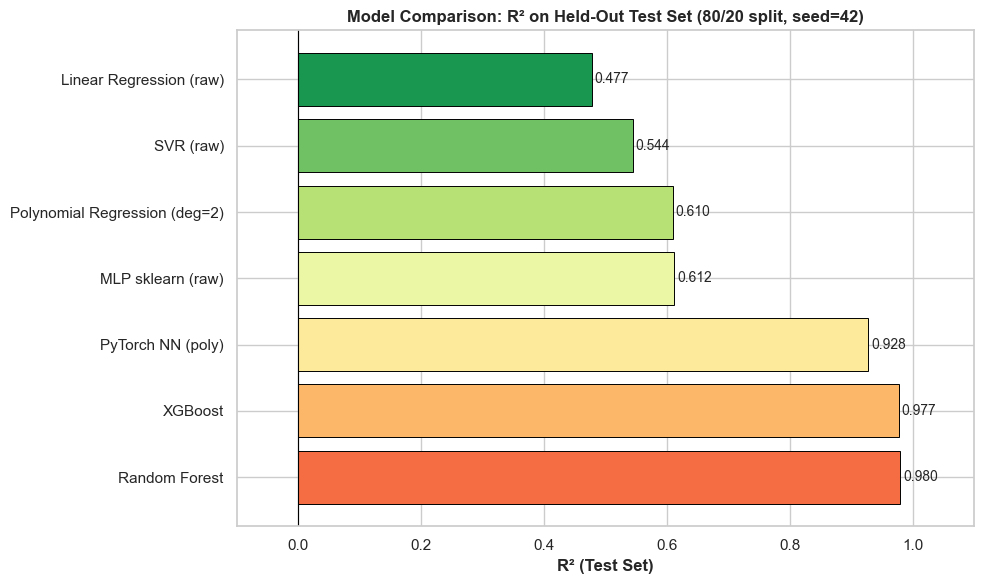

Figure saved.


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

models_plot = df_results.copy().reset_index()
models_plot.columns = ['Model', 'R2_test', 'RMSE_test', 'R2_CV']

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(models_plot)))

bars = ax.barh(models_plot['Model'], models_plot['R2_test'], color=colors, edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, models_plot['R2_test']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('R² (Test Set)', fontweight='bold')
ax.set_title('Model Comparison: R² on Held-Out Test Set (80/20 split, seed=42)',
             fontweight='bold')
ax.set_xlim(-0.1, 1.1)
plt.tight_layout()
plt.savefig('../static/images/baselines_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('validation_images/baselines_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved.')

## SFB verification (Task 5)

Documents the **correct** reason for excluding % SFB from the feature set.

In [15]:
import numpy.linalg as linalg

print('=== SFB VERIFICATION ===')

# 1. Distribution of DMSO + Trehalose + SFB sum
df2 = df.copy()
df2['SUM'] = df2['% DMSO'] + df2['TREHALOSE'] + df2['% SFB']
sum_counts = df2['SUM'].value_counts().sort_index()
print('Sum DMSO + Trehalose + SFB value counts:')
print(sum_counts.to_string())
n_100 = (df2['SUM'] == 100).sum()
n_10  = (df2['SUM'] == 10).sum()
print(f'\n  Rows summing to 100: {n_100} / {len(df2)}')
print(f'  Rows summing to 10:  {n_10} / {len(df2)}')

# 2. Rank of design matrix [1, DMSO, Trehalose, SFB]
M = np.column_stack([
    np.ones(len(df2)),
    df2['% DMSO'].values,
    df2['TREHALOSE'].values,
    df2['% SFB'].values
])
rank = np.linalg.matrix_rank(M)
print(f'\nRank of [1, DMSO, Trehalose, SFB] matrix ({M.shape}): {rank}')
print(f'  Full rank (4) = {rank == 4} — matrix is NOT rank-deficient')

# 3. How well can SFB be predicted from DMSO + Trehalose (linear)?
from sklearn.linear_model import LinearRegression as LR
sfb_model = LR().fit(
    df2[['% DMSO', 'TREHALOSE']].values,
    df2['% SFB'].values
)
r2_sfb = sfb_model.score(df2[['% DMSO', 'TREHALOSE']].values, df2['% SFB'].values)
print(f'\nR²(SFB ~ DMSO + Trehalose, linear): {r2_sfb:.4f}')
print(f'  SFB is ~{r2_sfb*100:.1f}% linearly predictable from DMSO + Trehalose')

# 4. RF performance WITH SFB
X_sfb = df2[['% DMSO', 'TREHALOSE', '% SFB']].values
X_train_sfb, X_test_sfb, _, _ = train_test_split(X_sfb, y, test_size=0.2, random_state=SEED)
rf_sfb = RandomForestRegressor(n_estimators=200, random_state=SEED)
rf_sfb.fit(X_train_sfb, y_train)
r2_sfb_test = r2_score(y_test, rf_sfb.predict(X_test_sfb))
fi_sfb = dict(zip(['DMSO', 'Trehalose', 'SFB'], rf_sfb.feature_importances_))
print(f'\nRF with SFB:    R²(test) = {r2_sfb_test:.4f}')
print(f'RF without SFB: R²(test) = {r2_rf_test:.4f}')
print(f'  Delta R²: {r2_sfb_test - r2_rf_test:+.4f} (marginal gain)')
print(f'\nFeature importances WITH SFB:')
for k, v in fi_sfb.items():
    print(f'  {k}: {v:.4f}')

print(f'\nFeature importances WITHOUT SFB:')
for k, v in zip(['DMSO', 'Trehalose'], rf.feature_importances_):
    print(f'  {k}: {v:.4f}')

print("""
CORRECT JUSTIFICATION FOR SFB EXCLUSION:
  (a) SFB adds negligible predictive value (RF R² unchanged or marginally different).
  (b) Including SFB inflates its apparent importance at the expense of DMSO,
      because SFB ≈ balance concentration (diluent / complement), not an
      independently optimized factor — the correlation is confounded, not causal.
  (c) The matrix [1, DMSO, Trehalose, SFB] has full rank (no exact linear
      dependency across all rows) because 8 rows sum to 10 instead of 100.
      The INCORRECT original claim was that SFB = 100 - DMSO - Trehalose always.
""")

=== SFB VERIFICATION ===
Sum DMSO + Trehalose + SFB value counts:
SUM
10.0       8
100.0    208

  Rows summing to 100: 208 / 216
  Rows summing to 10:  8 / 216

Rank of [1, DMSO, Trehalose, SFB] matrix ((216, 4)): 4
  Full rank (4) = True — matrix is NOT rank-deficient

R²(SFB ~ DMSO + Trehalose, linear): 0.7083
  SFB is ~70.8% linearly predictable from DMSO + Trehalose



RF with SFB:    R²(test) = 0.9798
RF without SFB: R²(test) = 0.9797
  Delta R²: +0.0001 (marginal gain)

Feature importances WITH SFB:
  DMSO: 0.6552
  Trehalose: 0.0973
  SFB: 0.2475

Feature importances WITHOUT SFB:
  DMSO: 0.7768
  Trehalose: 0.2232

CORRECT JUSTIFICATION FOR SFB EXCLUSION:
  (a) SFB adds negligible predictive value (RF R² unchanged or marginally different).
  (b) Including SFB inflates its apparent importance at the expense of DMSO,
      because SFB ≈ balance concentration (diluent / complement), not an
      independently optimized factor — the correlation is confounded, not causal.
  (c) The matrix [1, DMSO, Trehalose, SFB] has full rank (no exact linear
      dependency across all rows) because 8 rows sum to 10 instead of 100.
      The INCORRECT original claim was that SFB = 100 - DMSO - Trehalose always.



## Polynomial feature correlation (Strobl et al. 2008 issue)

In [16]:
dmso  = X_raw[:, 0]
dmso2 = dmso ** 2

corr_dmso_dmso2 = np.corrcoef(dmso, dmso2)[0, 1]
r2_dmso2_from_dmso = LinearRegression().fit(dmso.reshape(-1, 1), dmso2).score(dmso.reshape(-1, 1), dmso2)

print(f'corr(DMSO, DMSO²) = {corr_dmso_dmso2:.4f}')
print(f'R²(DMSO² ~ DMSO, linear) = {r2_dmso2_from_dmso:.4f}')
print()
print('High correlation between DMSO and DMSO² means that when both are given to')
print('a Random Forest, Gini importance distributes credit arbitrarily between them')
print('(Strobl et al., 2008, BMC Bioinformatics 9:307).')
print('This is why feature importance should ONLY use raw features [DMSO, Trehalose].')

corr(DMSO, DMSO²) = 0.9586
R²(DMSO² ~ DMSO, linear) = 0.9189

High correlation between DMSO and DMSO² means that when both are given to
a Random Forest, Gini importance distributes credit arbitrarily between them
(Strobl et al., 2008, BMC Bioinformatics 9:307).
This is why feature importance should ONLY use raw features [DMSO, Trehalose].
